In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_DIR = Path("./data")
MAXWSPD_DIR = DATA_DIR / "maxwspd_interval1h"
BEST_TRACK_FILE = DATA_DIR / "best_track_Ragasa_JMA.xlsx"
OUTPUT_DIR = Path(".")

FORECAST_INIT_TIMES = {
    "24h": pd.Timestamp("2025-09-22 22:00"),
    "48h": pd.Timestamp("2025-09-21 22:00"),
}
MODEL_STYLES = {
    "era5": {"label": "ERA5_WRF", "color": "#4c78a8", "marker": "x"},
    "pangu": {"label": "Pangu_WRF", "color": "#f58518", "marker": "s"},
    "graphcast": {"label": "GraphCast_WRF", "color": "#54a24b", "marker": "^"},
    "fengwu": {"label": "FengWu_WRF", "color": "#e45756", "marker": "D"},
    "fuxi": {"label": "FuXi_WRF", "color": "#72b7b2", "marker": "v"},
    "aurora": {"label": "Aurora_WRF", "color": "#b279a2", "marker": "p"},
}

KT_TO_MS = 0.514444
TIME_MARGIN = pd.Timedelta(hours=2)
HONG_KONG_NEAREST_TIME = pd.Timestamp("2025-09-23 22:00")
Y_LABEL = r"Intensity (m s$^{-1}$)"
X_LABEL = "Time (UTC, 2025)"
X_TICK_INTERVAL_HOURS = 12
X_MINOR_TICK_INTERVAL_HOURS = 6
FIG_SIZE = (8, 4)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 16

def load_maxwspd_forecast(model, cycle, init_time):
    values = np.loadtxt(MAXWSPD_DIR / f"maxwspd_d01_interval1h_{model}_{cycle}.txt")
    values = np.atleast_2d(values)
    lead_hour = np.arange(values.shape[0], dtype=int)
    return pd.DataFrame(
        {
            "model": model,
            "cycle": cycle,
            "lead_hour": lead_hour,
            "init_time": pd.Timestamp(init_time),
            "valid_time": pd.Timestamp(init_time) + pd.to_timedelta(lead_hour, unit="h"),
            "lon": values[:, 0],
            "lat": values[:, 1],
            "forecast_maxwind_ms": values[:, 2],
        }
    )

def load_best_track(file_path):
    return (
        pd.read_excel(file_path)
        .rename(columns={"Time": "time", "Wind": "wind_kt"})
        .assign(
            time=lambda df: pd.to_datetime(df["time"].astype(str), format="%y%m%d%H"),
            wind_kt=lambda df: pd.to_numeric(df["wind_kt"], errors="coerce"),
            wind_ms=lambda df: pd.to_numeric(df["wind_kt"], errors="coerce") * KT_TO_MS,
        )
        [["time", "wind_kt", "wind_ms"]]
        .dropna(subset=["time", "wind_ms"])
        .sort_values("time")
        .reset_index(drop=True)
    )

def prepare_cycle_series(cycle):
    init_time = FORECAST_INIT_TIMES[cycle]
    forecasts = {
        model: load_maxwspd_forecast(model, cycle, init_time)
        for model in MODEL_STYLES
    }

    forecast_end = min(track["valid_time"].max() for track in forecasts.values())
    best_track = load_best_track(BEST_TRACK_FILE)
    best_window = (
        best_track.loc[best_track["time"].between(init_time, forecast_end)]
        .copy()
        .sort_values("time")
        .reset_index(drop=True)
    )

    forecast_aligned = {}
    for model, forecast in forecasts.items():
        subset = (
            forecast.rename(columns={"valid_time": "time"})
            .merge(best_window, on="time", how="inner")
            .sort_values("time")
            .reset_index(drop=True)
        )
        forecast_aligned[model] = subset

    shared_times = pd.Index(best_window["time"])
    for forecast in forecast_aligned.values():
        shared_times = shared_times.intersection(pd.Index(forecast["time"]))

    best_aligned = (
        best_window.loc[best_window["time"].isin(shared_times)]
        .copy()
        .reset_index(drop=True)
    )
    forecast_aligned = {
        model: forecast.loc[forecast["time"].isin(shared_times)].copy().reset_index(drop=True)
        for model, forecast in forecast_aligned.items()
    }

    return {
        "cycle": cycle,
        "best_track": best_aligned,
        "forecast_aligned": forecast_aligned,
    }

def compute_shared_time_limits(cycle_series_map):
    all_times = []
    for cycle_data in cycle_series_map.values():
        all_times.append(cycle_data["best_track"]["time"])
        for forecast in cycle_data["forecast_aligned"].values():
            all_times.append(forecast["time"])

    combined_times = pd.concat(all_times, ignore_index=True)
    return combined_times.min() - TIME_MARGIN, combined_times.max() + TIME_MARGIN

def plot_cycle_panel(ax, cycle):
    cycle_data = cycle_series[cycle]
    best_track = cycle_data["best_track"]
    model_lines = []

    for model, forecast in cycle_data["forecast_aligned"].items():
        style = MODEL_STYLES[model]
        line, = ax.plot(
            forecast["time"],
            forecast["forecast_maxwind_ms"],
            color=style["color"],
            linewidth=1.2,
            marker=style["marker"],
            markersize=5,
            label=style["label"],
        )
        model_lines.append(line)

    best_line, = ax.plot(
        best_track["time"],
        best_track["wind_ms"],
        color="black",
        linewidth=1.5,
        marker="o",
        markersize=5,
        label="Best track",
    )

    ax.axvline(
        HONG_KONG_NEAREST_TIME,
        color="#444444",
        linestyle="--",
        linewidth=1.0,
        zorder=1,
    )
    ax.set_ylabel(Y_LABEL)
    ax.set_xlim(SHARED_TIME_LIMITS)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

    return model_lines + [best_line]

def format_time_axis(ax):
    ax.set_xlabel(X_LABEL)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=X_TICK_INTERVAL_HOURS))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %HZ"))
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=X_MINOR_TICK_INTERVAL_HOURS))
    ax.tick_params(axis="x", which="minor", labelbottom=False, length=3)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

def plot_maxwspd_figure(cycle, output_name):
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    legend_lines = plot_cycle_panel(ax, cycle)
    format_time_axis(ax)
    ax.legend(
        legend_lines,
        [line.get_label() for line in legend_lines],
        loc="lower left",
        frameon=True,
        fontsize=12,
        ncol=2,
    )
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=600, format="tif", bbox_inches="tight")
    plt.show()

cycle_series = {cycle: prepare_cycle_series(cycle) for cycle in FORECAST_INIT_TIMES}
SHARED_TIME_LIMITS = compute_shared_time_limits(cycle_series)
cycle_series["24h"]["best_track"]

,time,wind_kt,wind_ms
0,2025-09-23 00:00:00,105,54.01662
1,2025-09-23 06:00:00,100,51.44440
2,2025-09-23 12:00:00,100,51.44440
3,2025-09-23 18:00:00,100,51.44440
4,2025-09-24 00:00:00,95,48.87218
5,2025-09-24 06:00:00,90,46.29996


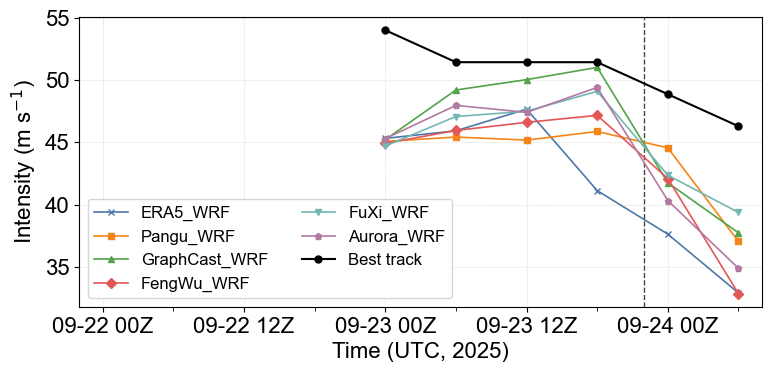

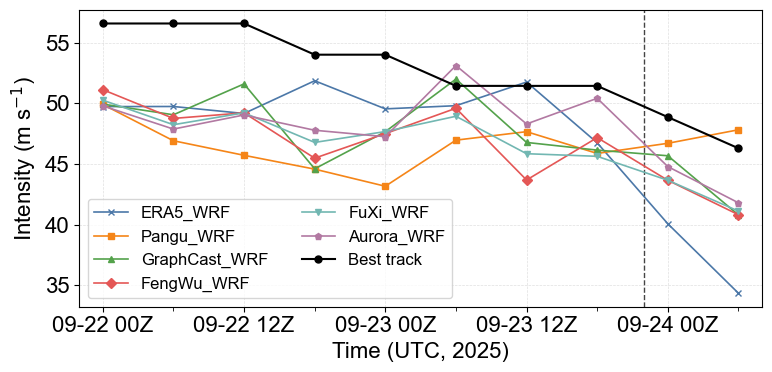

In [3]:
plot_maxwspd_figure("24h", "maxwspd_forecast_24h.tif")
plot_maxwspd_figure("48h", "maxwspd_forecast_48h.tif")